# Dataset Columns — Powerlifting Database

| Column | Meaning |
|---|---|
| `MeetID` | Unique identifier assigned to each powerlifting competition (meet). |
| `Name` | Name of the powerlifter or athlete. |
| `Sex` | Sex of the athlete. |
| `Equipment` | Type of lifting equipment used, such as Raw, Wraps, Single-ply, or Multi-ply. |
| `Age` | Age of the athlete at the time of the competition. |
| `Division` | Competition division of the athlete, such as Open, Junior, or Masters. |
| `BodyweightKg` | Body weight of the athlete in kilograms at the competition. |
| `WeightClassKg` | Weight class/category in which the athlete competed, measured in kilograms. |
| `Squat4Kg` | Weight attempted by the athlete in the 4th squat attempt, when recorded. |
| `BestSquatKg` | Best successful squat weight lifted by the athlete, in kilograms. |
| `Bench4Kg` | Weight attempted by the athlete in the 4th bench press attempt, when recorded. |
| `BestBenchKg` | Best successful bench press weight lifted by the athlete, in kilograms. |
| `Deadlift4Kg` | Weight attempted by the athlete in the 4th deadlift attempt, when recorded. |
| `BestDeadliftKg` | Best successful deadlift weight lifted by the athlete, in kilograms. |
| `TotalKg` | Total powerlifting weight, calculated as Best Squat + Best Bench + Best Deadlift. |
| `Place` | Final finishing position of the athlete in the competition/division. |
| `Wilks` | Wilks score, a bodyweight-adjusted measure used to compare powerlifting performance between athletes of different body weights. |

🎯 Target Variable — TotalKg

`TotalKg` represents the **total weight lifted by a powerlifter** across the three main powerlifting movements:

- **Squat**
- **Bench Press**
- **Deadlift**


The model will learn the relationship between athlete/competition characteristics and the total weight lifted.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv(r'/content/openpowerlifting.csv')

print(f"Shape: {df.shape}")
print(df.head())
print(df.tail())


Shape: (386414, 17)
   MeetID              Name Sex   Equipment   Age     Division  BodyweightKg  \
0       0  Angie Belk Terry   F       Wraps  47.0    Mst 45-49         59.60   
1       0       Dawn Bogart   F  Single-ply  42.0    Mst 40-44         58.51   
2       0       Dawn Bogart   F  Single-ply  42.0  Open Senior         58.51   
3       0       Dawn Bogart   F         Raw  42.0  Open Senior         58.51   
4       0      Destiny Dula   F         Raw  18.0   Teen 18-19         63.68   

  WeightClassKg  Squat4Kg  BestSquatKg  Bench4Kg  BestBenchKg  Deadlift4Kg  \
0            60       NaN        47.63       NaN        20.41          NaN   
1            60       NaN       142.88       NaN        95.25          NaN   
2            60       NaN       142.88       NaN        95.25          NaN   
3            60       NaN          NaN       NaN        95.25          NaN   
4          67.5       NaN          NaN       NaN        31.75          NaN   

   BestDeadliftKg  TotalKg Pla

In [ ]:
df.columns

Index(['MeetID', 'Name', 'Sex', 'Equipment', 'Age', 'Division', 'BodyweightKg',
       'WeightClassKg', 'Squat4Kg', 'BestSquatKg', 'Bench4Kg', 'BestBenchKg',
       'Deadlift4Kg', 'BestDeadliftKg', 'TotalKg', 'Place', 'Wilks'],
      dtype='object')

In [ ]:
schema = pd.DataFrame({
    "Column": df.columns,
    "Dtype": df.dtypes,
    "Non_Null": df.notna().sum().values,
    "Missing": df.isna().sum().values,
    "Missing_%": (df.isna().mean()*100).values,
    "Unique": df.nunique(dropna=False).values
})

print(schema)


                        Column    Dtype  Non_Null  Missing  Missing_%  Unique
MeetID                  MeetID    int64    386414        0   0.000000    8482
Name                      Name   object    386414        0   0.000000  136687
Sex                        Sex   object    386414        0   0.000000       2
Equipment            Equipment   object    386414        0   0.000000       5
Age                        Age  float64    147147   239267  61.919858     168
Division              Division   object    370571    15843   4.100007    4247
BodyweightKg      BodyweightKg  float64    384012     2402   0.621613    9111
WeightClassKg    WeightClassKg   object    382602     3812   0.986507      52
Squat4Kg              Squat4Kg  float64      1243   385171  99.678324     439
BestSquatKg        BestSquatKg  float64    298071    88343  22.862267    1508
Bench4Kg              Bench4Kg  float64      1962   384452  99.492254     527
BestBenchKg        BestBenchKg  float64    356364    30050   7.7

In [ ]:
# Duplicate analysis

dup = df.duplicated()
print("Duplicate rows:", dup.sum())
print("Duplicate percentage:", round(dup.mean()*100, 3))


Duplicate rows: 545
Duplicate percentage: 0.141


In [ ]:
# Identifier/cardinality audit

for col in ["MeetID", "Name"]:
    if col in df.columns:
        print(f"{col}: {df[col].nunique(dropna=False):,} unique values")
        print(f"Rows per unique {col}: {len(df)/max(df[col].nunique(),1):.2f}")
        print()


MeetID: 8,482 unique values
Rows per unique MeetID: 45.56

Name: 136,687 unique values
Rows per unique Name: 2.83



In [ ]:
# Negative values : Which numerical columns contain negative values, how many negative values they have, and what percentage of the dataset they represent.

negative_cols = []
for col in df.select_dtypes(include=np.number).columns:
    count = (df[col] < 0).sum()
    negative_cols.append([col, count, count/len(df)*100])

negative_summary = pd.DataFrame(
    negative_cols,
    columns=["Column","Negative_Count","Negative_%"]
).sort_values("Negative_Count", ascending=False)

print(negative_summary)


            Column  Negative_Count  Negative_%
6      BestBenchKg            1556    0.402677
4      BestSquatKg             985    0.254908
5         Bench4Kg             660    0.170801
8   BestDeadliftKg             511    0.132242
7      Deadlift4Kg             494    0.127842
3         Squat4Kg             233    0.060298
0           MeetID               0    0.000000
2     BodyweightKg               0    0.000000
1              Age               0    0.000000
9          TotalKg               0    0.000000
10           Wilks               0    0.000000


In [ ]:
# Domain validity checks

checks = {}

if "Age" in df:
    checks["Age <= 0"] = (df["Age"] <= 0).sum()
    checks["Age > 100"] = (df["Age"] > 100).sum()

if "BodyweightKg" in df:
    checks["BodyweightKg <= 0"] = (df["BodyweightKg"] <= 0).sum()

for c in ["BestSquatKg","BestBenchKg","BestDeadliftKg","TotalKg"]:
    if c in df:
        checks[f"{c} <= 0"] = (df[c] <= 0).sum()

print(pd.Series(checks, name="Count").to_frame())


                     Count
Age <= 0                 0
Age > 100                0
BodyweightKg <= 0        0
BestSquatKg <= 0       985
BestBenchKg <= 0      1556
BestDeadliftKg <= 0    511
TotalKg <= 0             0


In [ ]:
#  Missingness

missing = pd.DataFrame({
    "Count": df.isna().sum(),
    "Percentage": df.isna().mean()*100
}).sort_values("Percentage", ascending=False)

print(missing)


                 Count  Percentage
Squat4Kg        385171   99.678324
Bench4Kg        384452   99.492254
Deadlift4Kg     383614   99.275389
Age             239267   61.919858
BestSquatKg      88343   22.862267
BestDeadliftKg   68567   17.744440
BestBenchKg      30050    7.776633
Wilks            24220    6.267889
TotalKg          23177    5.997971
Division         15843    4.100007
WeightClassKg     3812    0.986507
BodyweightKg      2402    0.621613
Place             1092    0.282598
MeetID               0    0.000000
Sex                  0    0.000000
Equipment            0    0.000000
Name                 0    0.000000


###Univariate Analysis

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

num_summary = df[numeric_cols].describe().T
num_summary["missing"] = df[numeric_cols].isna().sum()
num_summary["missing_%"] = df[numeric_cols].isna().mean()*100
num_summary["skewness"] = df[numeric_cols].skew()
num_summary["kurtosis"] = df[numeric_cols].kurtosis()
num_summary["n_unique"] = df[numeric_cols].nunique()

print(num_summary)

                   count         mean          std     min      25%      50%  \
MeetID          386414.0  5143.015804  2552.099838    0.00  2979.00  5960.00   
Age             147147.0    31.668237    12.900342    5.00    22.00    28.00   
BodyweightKg    384012.0    86.934912    23.140843   15.88    70.30    83.20   
Squat4Kg          1243.0   107.036404   166.976620 -440.50    87.50   145.00   
BestSquatKg     298071.0   176.569941    69.222785 -477.50   127.50   174.63   
Bench4Kg          1962.0    45.722905   151.668221 -360.00   -90.00    90.25   
BestBenchKg     356364.0   118.347509    54.848850 -522.50    79.38   115.00   
Deadlift4Kg       2800.0   113.597193   170.201657 -461.00   110.00   157.50   
BestDeadliftKg  317847.0   195.040633    61.580675 -410.00   147.50   195.00   
TotalKg         363237.0   424.000249   196.355147   11.00   272.16   424.11   
Wilks           362194.0   301.080601   116.360396   13.73   237.38   319.66   

                    75%      max  missi

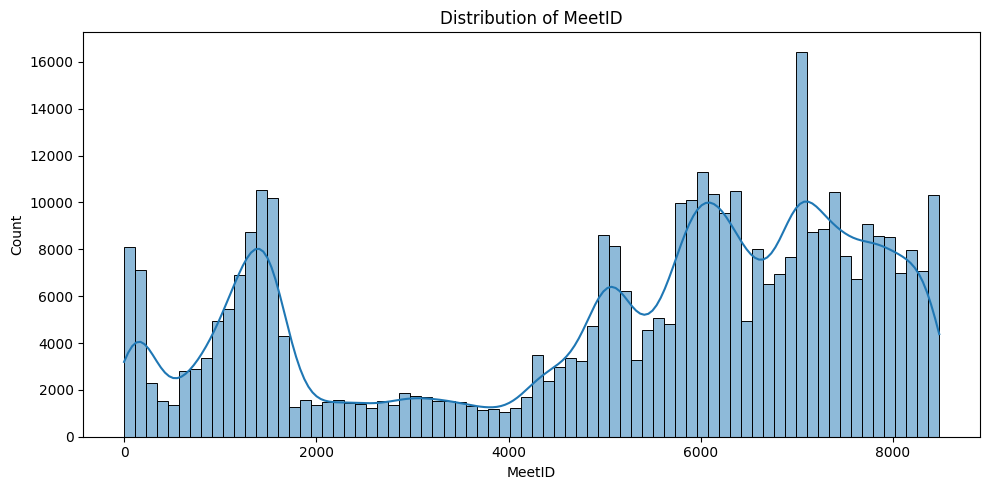

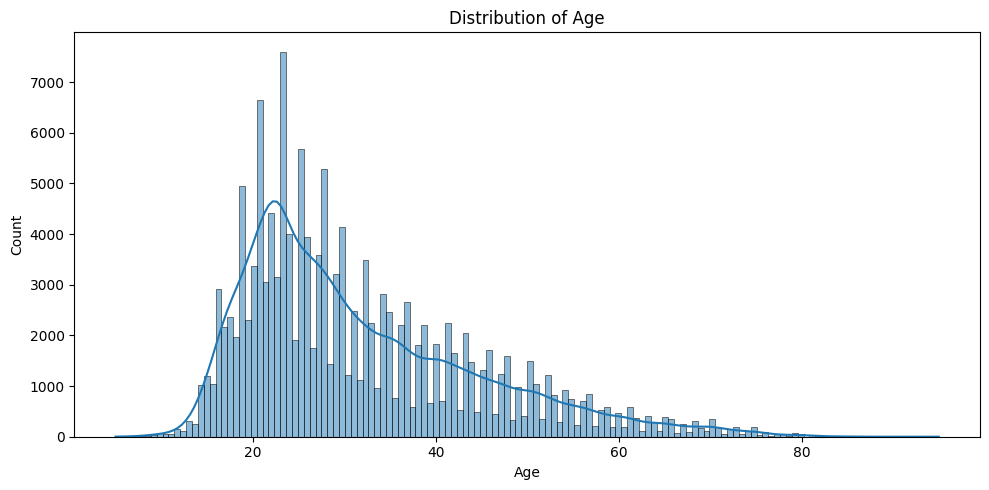

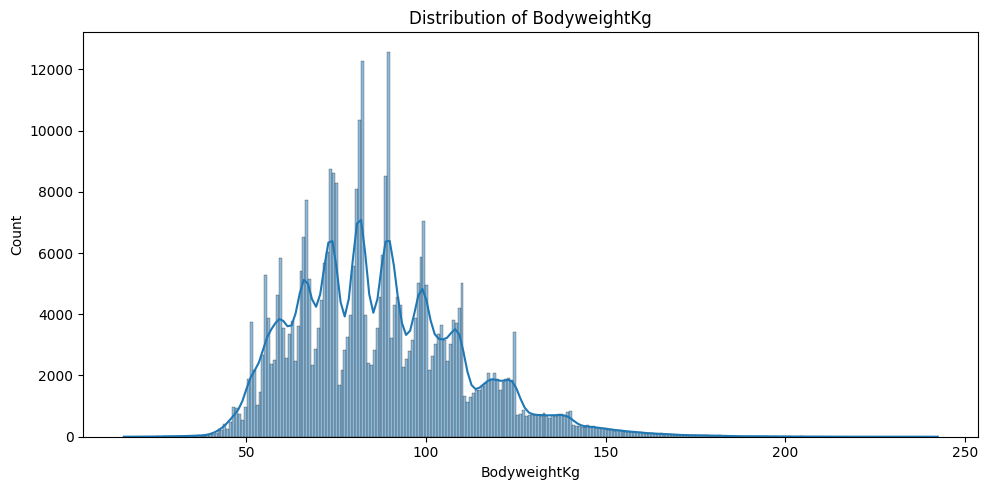

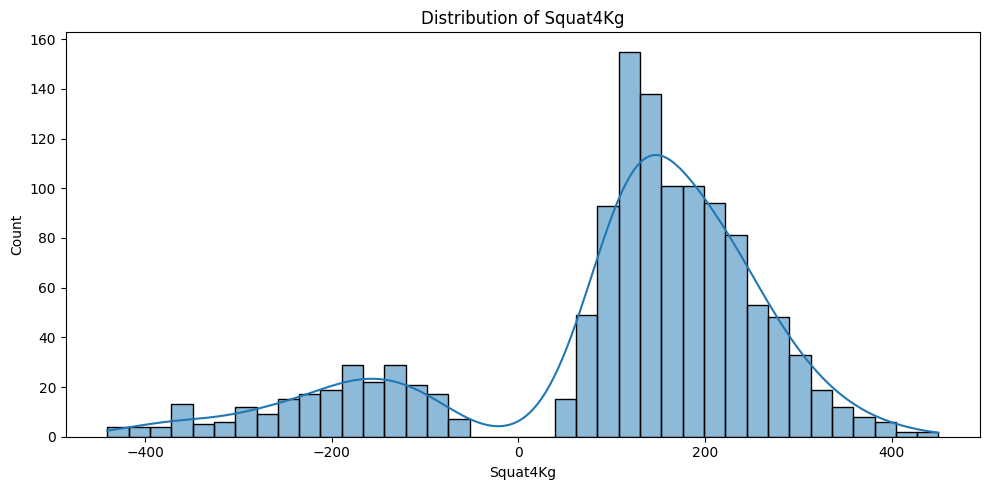

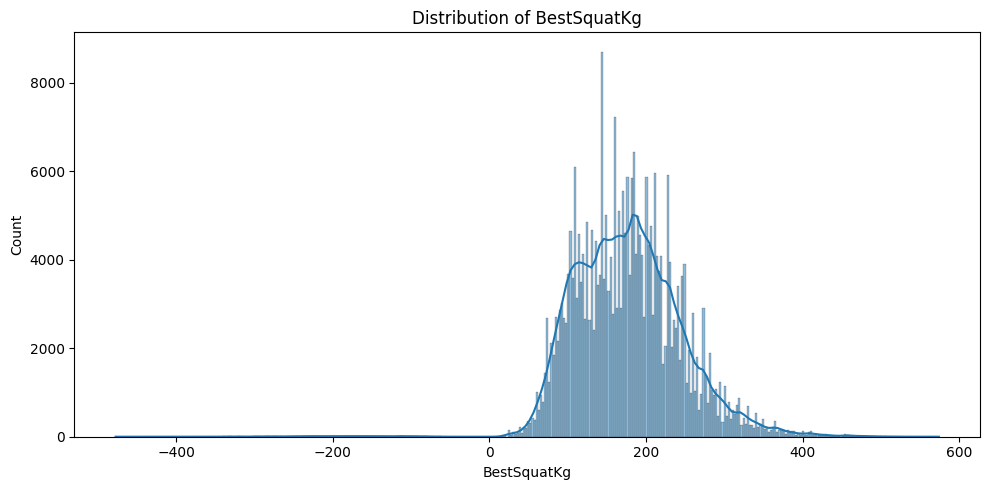

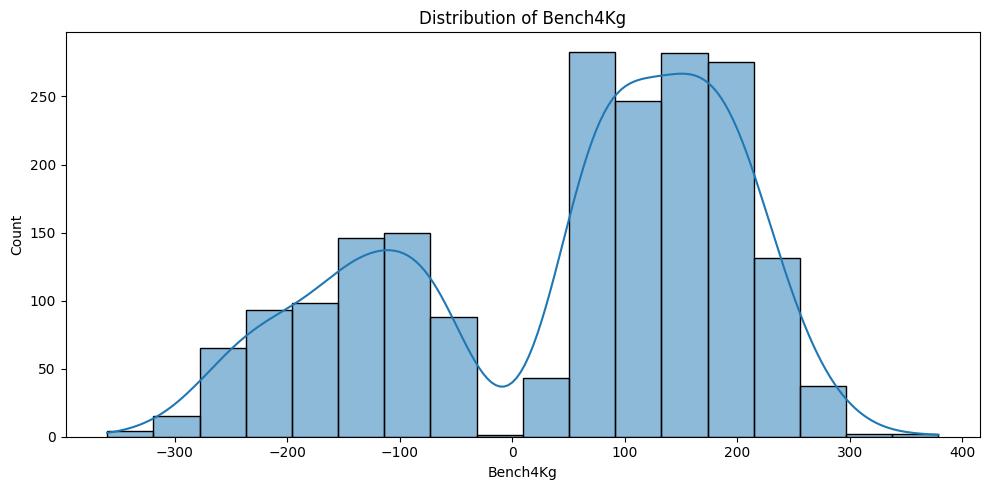

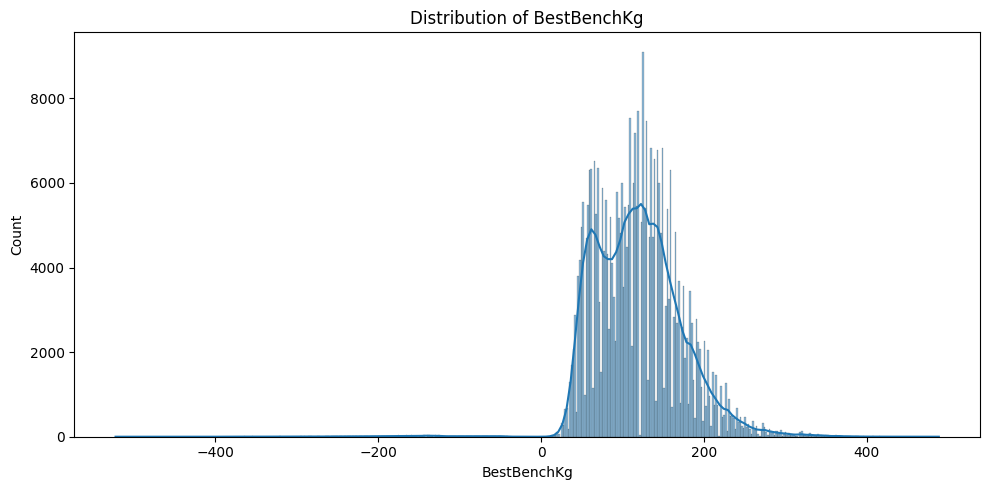

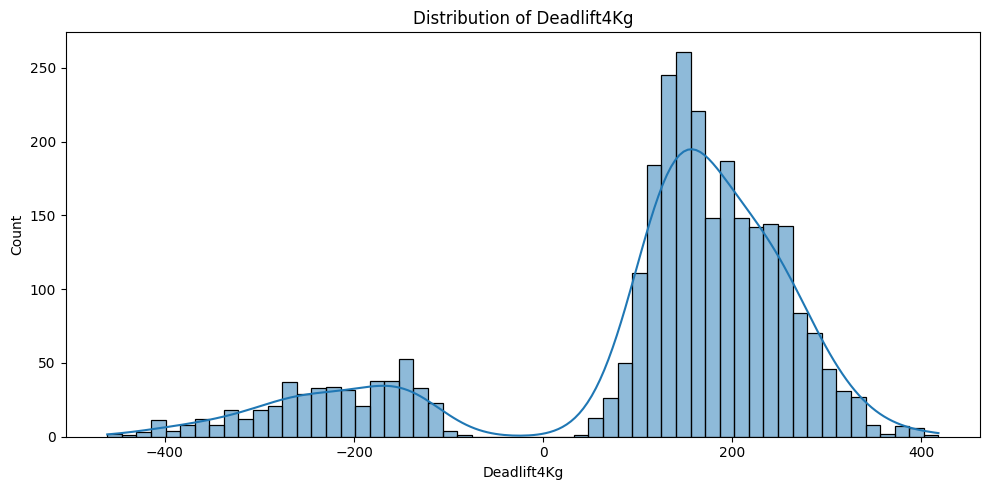

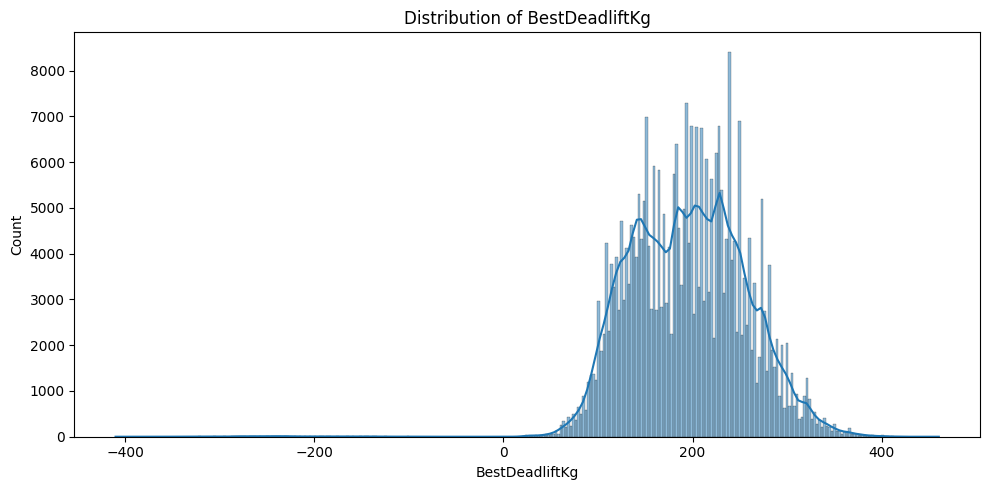

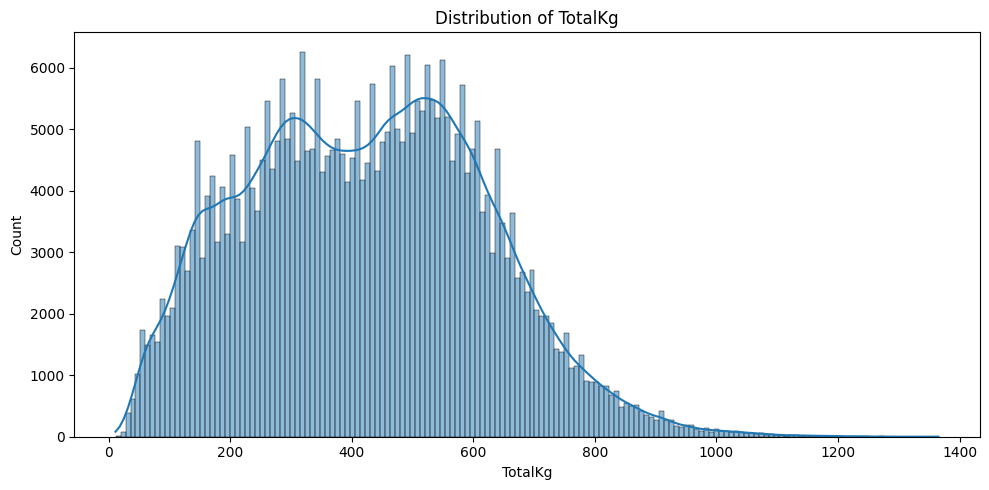

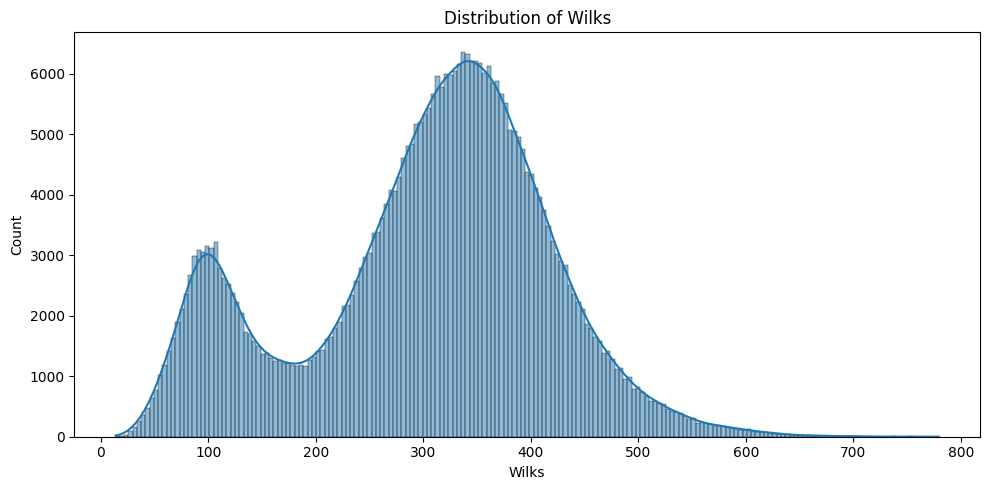

In [ ]:
# Distribution plots

for col in numeric_cols:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    plt.tight_layout()
    plt.show()


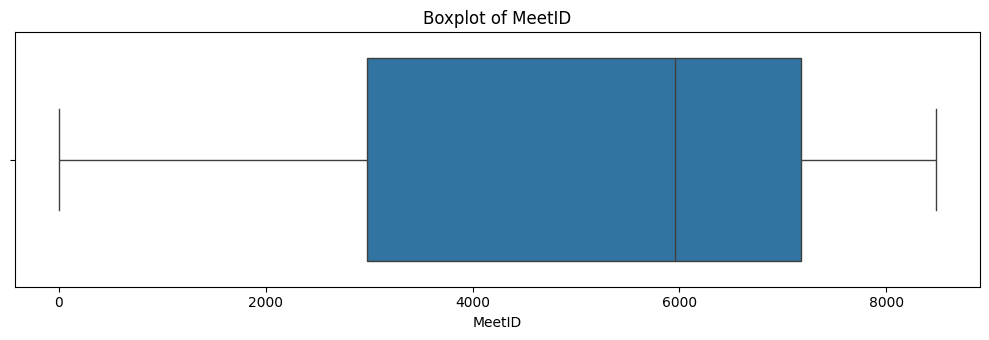

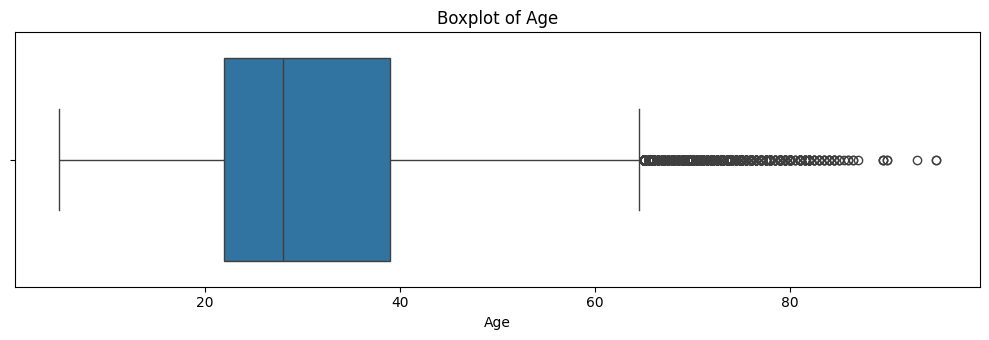

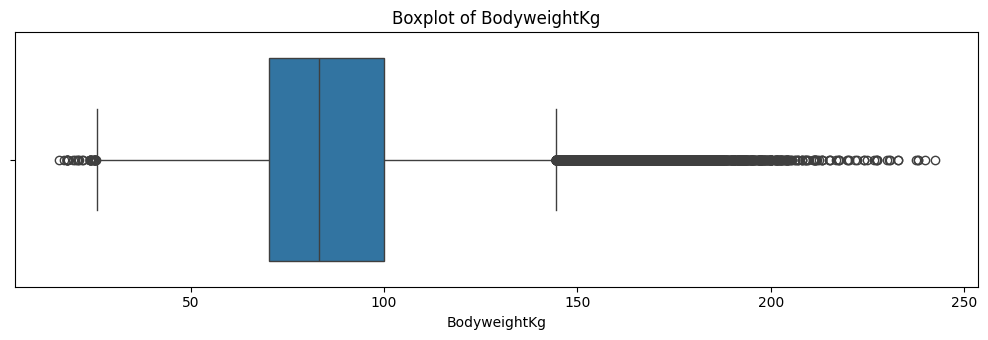

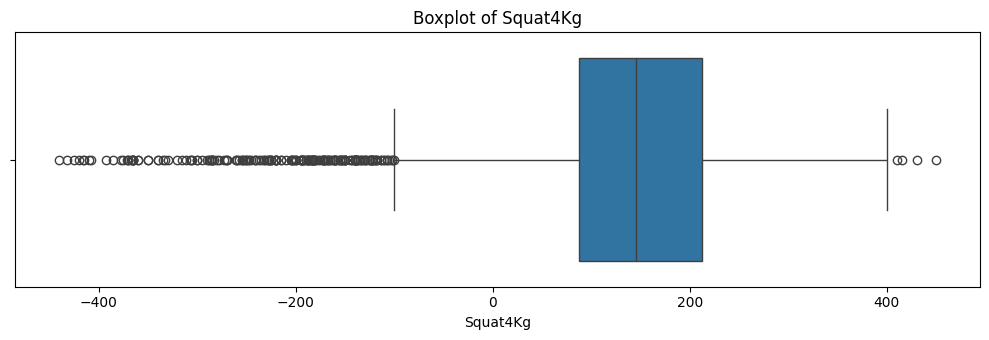

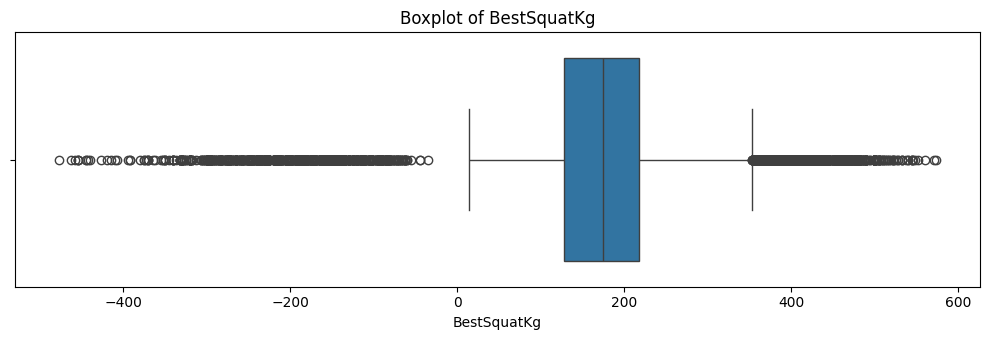

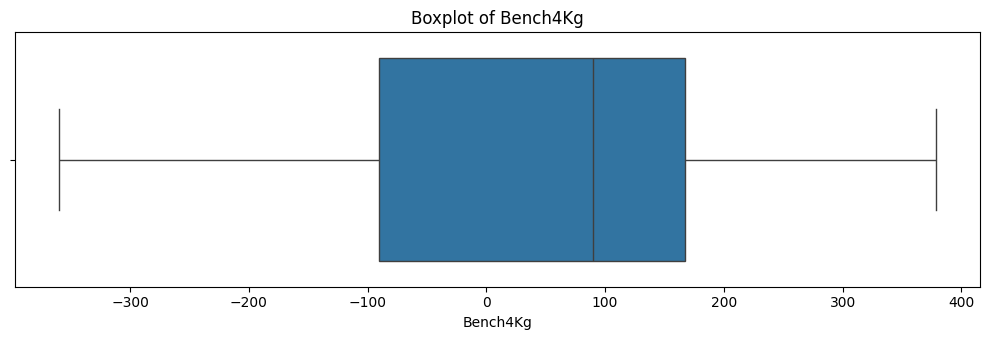

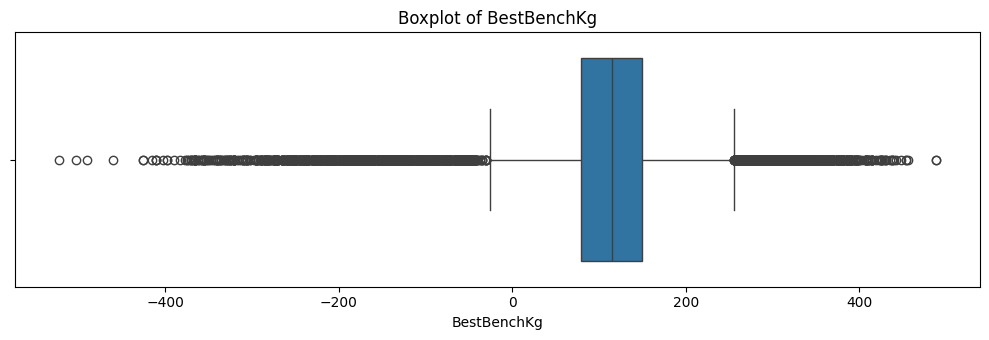

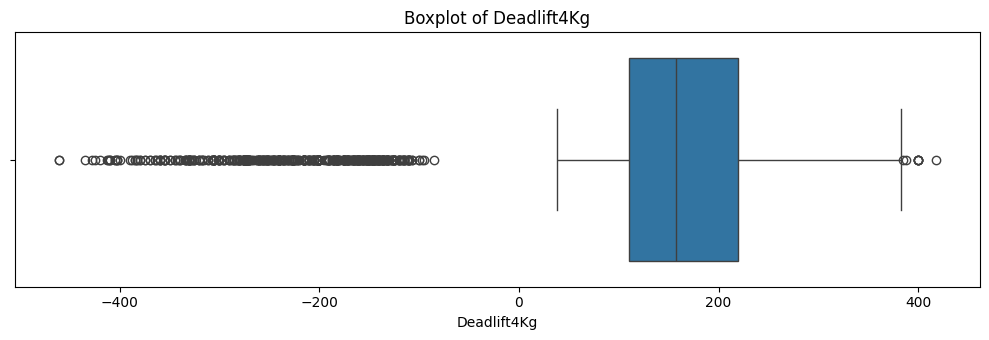

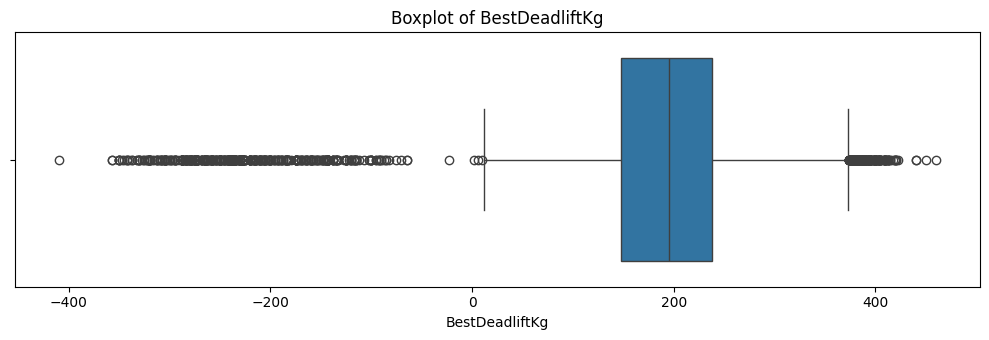

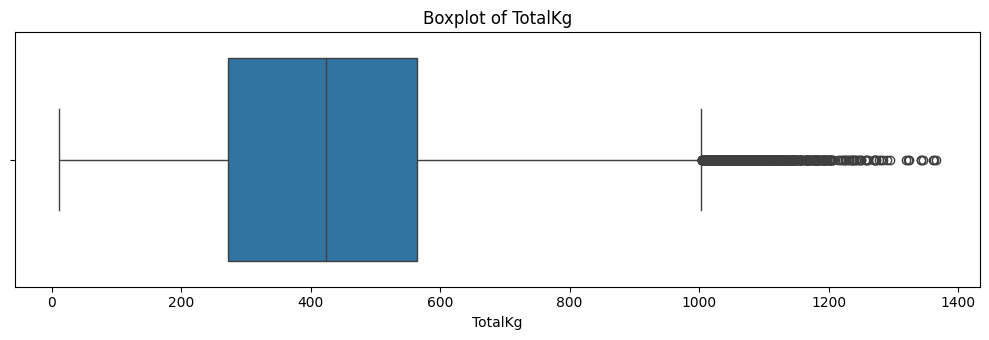

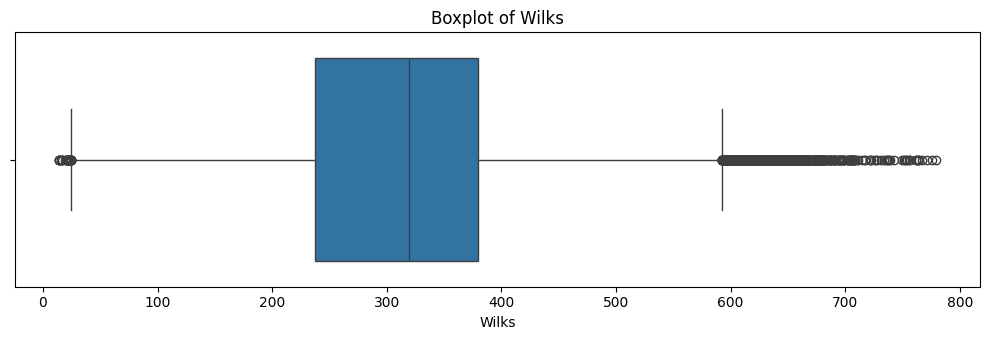

In [ ]:
# Boxplots

for col in numeric_cols:
    plt.figure(figsize=(10, 3.5))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()


In [ ]:
outlier_rows=[]

for col in numeric_cols:
    s=df[col].dropna()
    q1=s.quantile(.25)
    q3=s.quantile(.75)
    iqr=q3-q1
    low=q1-1.5*iqr
    high=q3+1.5*iqr

    outlier_rows.append({
        "Column":col,
        "Q1":q1,
        "Q3":q3,
        "IQR":iqr,
        "Lower":low,
        "Upper":high
    })

outlier_summary=pd.DataFrame(outlier_rows ).sort_values( 'Upper' , ascending = False)
outlier_summary


,Column,Q1,Q3,IQR,Lower,Upper
0,MeetID,2979.00,7175.00,4196.00,-3315.000,13469.000
9,TotalKg,272.16,565.00,292.84,-167.100,1004.260
10,Wilks,237.38,379.29,141.91,24.515,592.155
5,Bench4Kg,-90.00,167.50,257.50,-476.250,553.750
3,Squat4Kg,87.50,212.50,125.00,-100.000,400.000
7,Deadlift4Kg,110.00,219.99,109.99,-54.985,384.975
8,BestDeadliftKg,147.50,238.14,90.64,11.540,374.100
4,BestSquatKg,127.50,217.72,90.22,-7.830,353.050
6,BestBenchKg,79.38,150.00,70.62,-26.550,255.930
2,BodyweightKg,70.30,100.00,29.70,25.750,144.550


###Bivariate Analysis

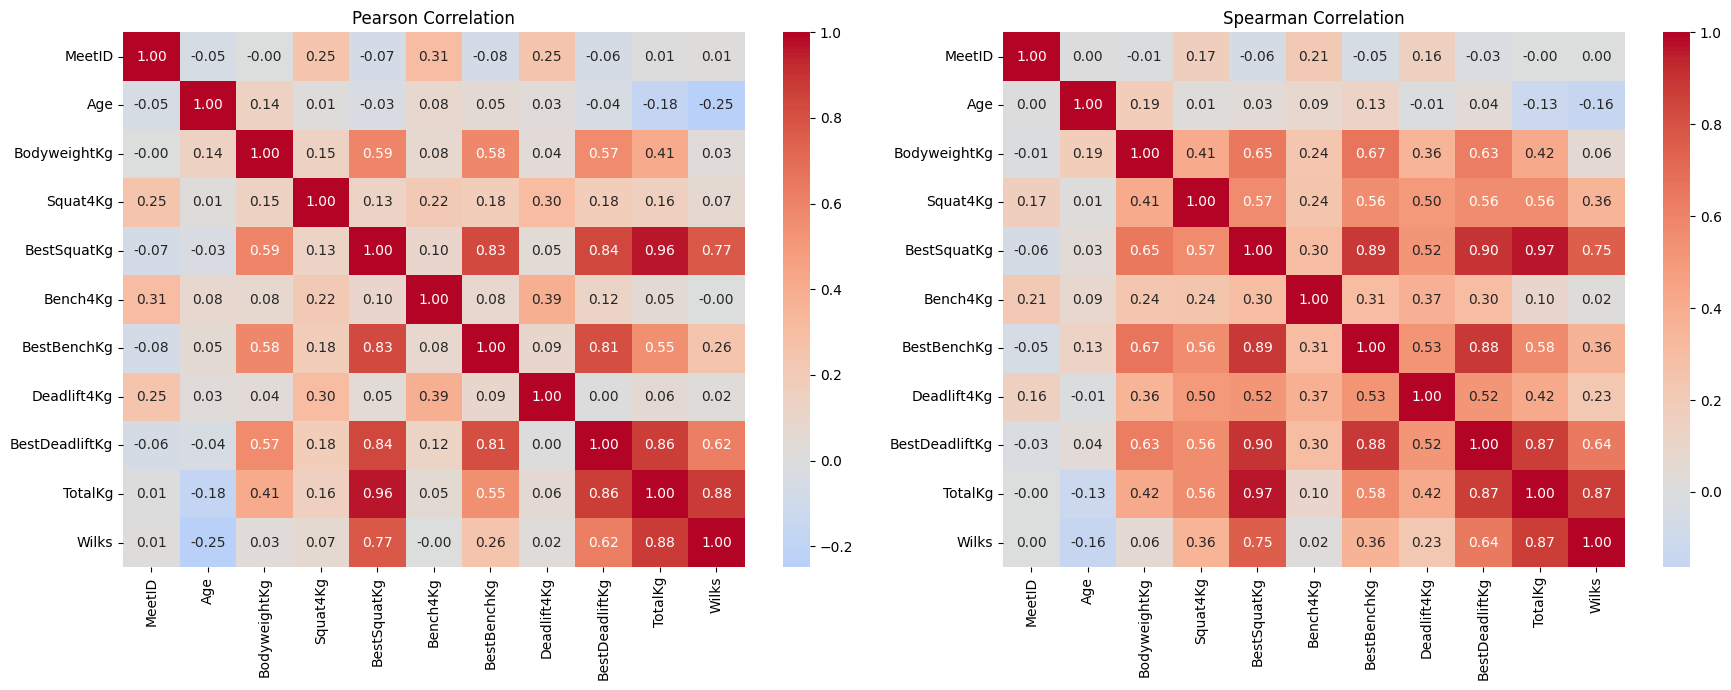

In [ ]:
# Pearson and Spearman correlation matrices

pearson=df[numeric_cols].corr(method="pearson")
spearman=df[numeric_cols].corr(method="spearman")

fig, axes=plt.subplots(1,2,figsize=(18,7))
sns.heatmap(pearson,annot=True,fmt=".2f",center=0,cmap="coolwarm",ax=axes[0])
axes[0].set_title("Pearson Correlation")
sns.heatmap(spearman,annot=True,fmt=".2f",center=0,cmap="coolwarm",ax=axes[1])
axes[1].set_title("Spearman Correlation")
plt.tight_layout()
plt.show()


In [ ]:
#  Rank strongest numerical relationships

corr_abs=pearson.abs()
pairs=[]

for i in range(len(corr_abs.columns)):
    for j in range(i+1,len(corr_abs.columns)):
        pairs.append({
            "Feature_1":corr_abs.columns[i],
            "Feature_2":corr_abs.columns[j],
            "Absolute_Pearson":corr_abs.iloc[i,j],
            "Pearson":pearson.iloc[i,j],
            "Spearman":spearman.iloc[i,j]
        })

print(pd.DataFrame(pairs).sort_values("Absolute_Pearson",ascending=False).head(30))


         Feature_1       Feature_2  Absolute_Pearson   Pearson  Spearman
38     BestSquatKg         TotalKg          0.964607  0.964607  0.965520
54         TotalKg           Wilks          0.878689  0.878689  0.868714
52  BestDeadliftKg         TotalKg          0.864350  0.864350  0.870232
37     BestSquatKg  BestDeadliftKg          0.841981  0.841981  0.901372
35     BestSquatKg     BestBenchKg          0.832890  0.832890  0.890782
46     BestBenchKg  BestDeadliftKg          0.811797  0.811797  0.882192
39     BestSquatKg           Wilks          0.771793  0.771793  0.750890
53  BestDeadliftKg           Wilks          0.615843  0.615843  0.641707
20    BodyweightKg     BestSquatKg          0.590903  0.590903  0.650464
22    BodyweightKg     BestBenchKg          0.584431  0.584431  0.667583
24    BodyweightKg  BestDeadliftKg          0.570754  0.570754  0.630010
47     BestBenchKg         TotalKg          0.551289  0.551289  0.577037
25    BodyweightKg         TotalKg          0.40570

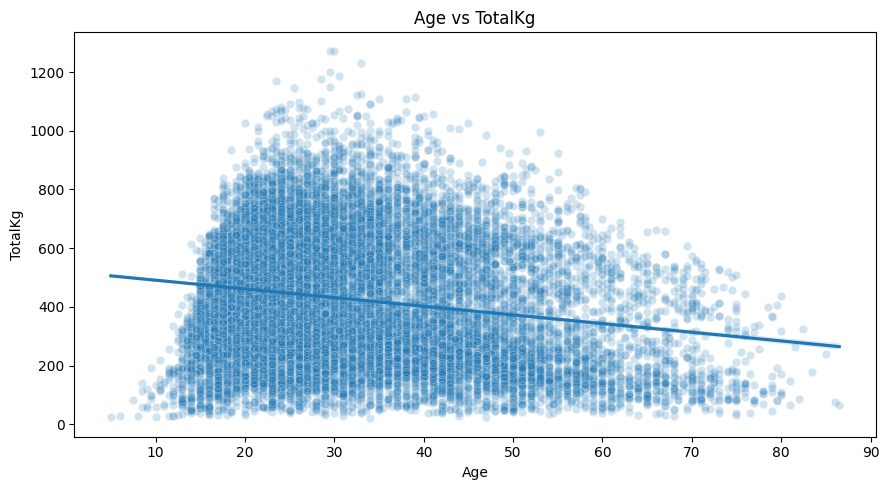

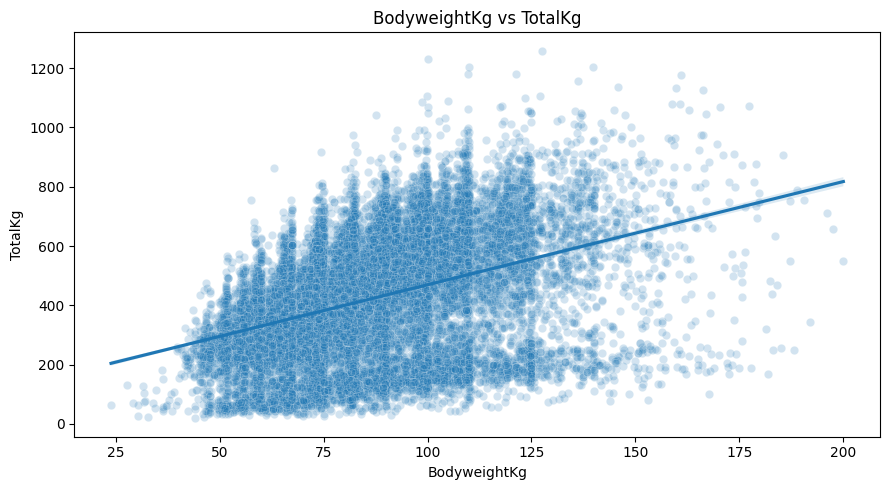

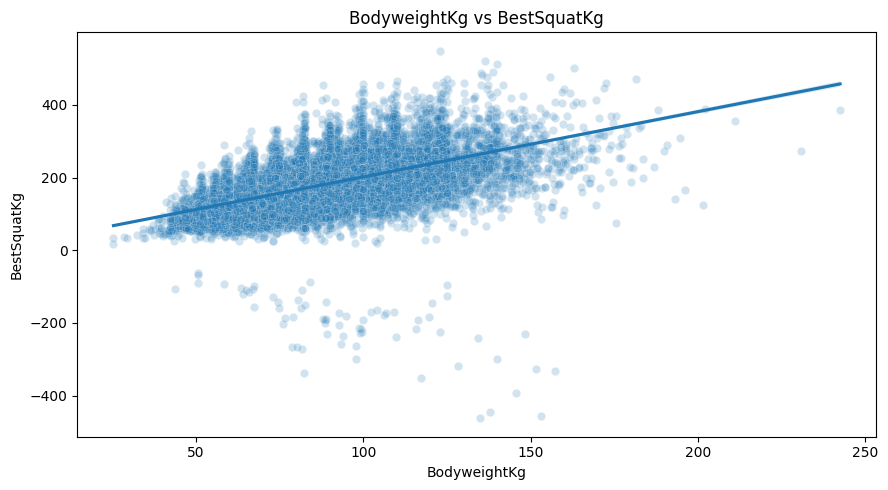

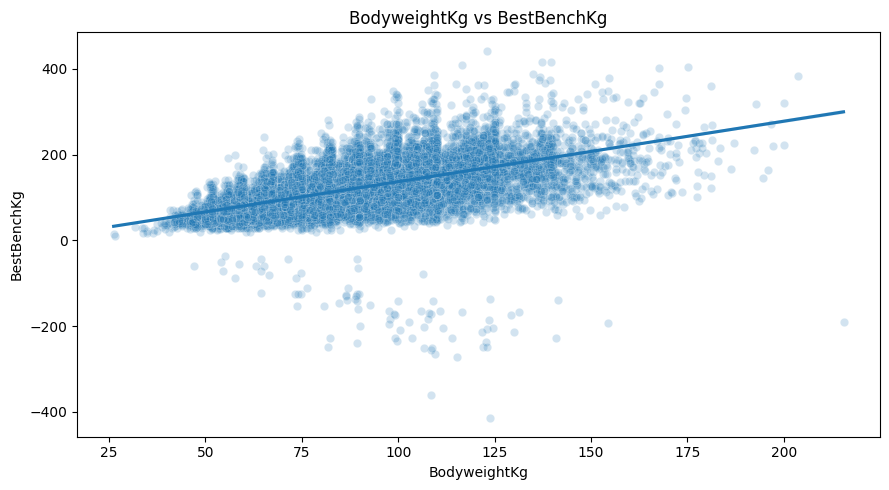

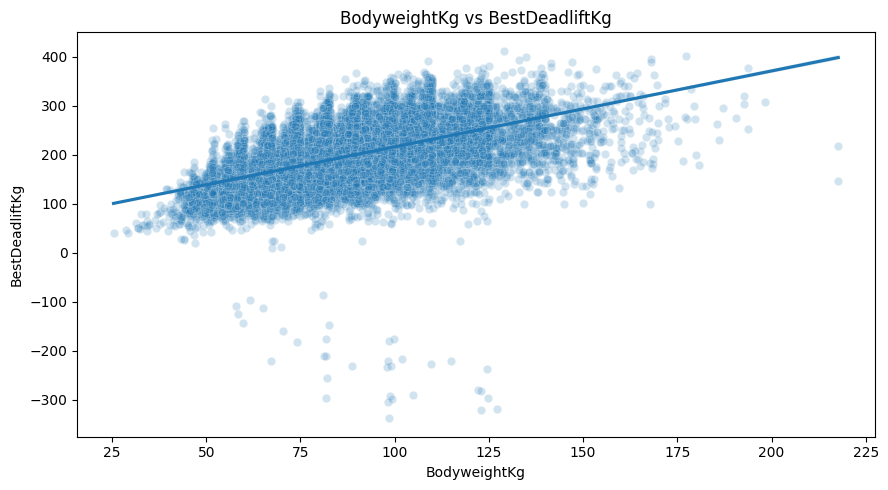

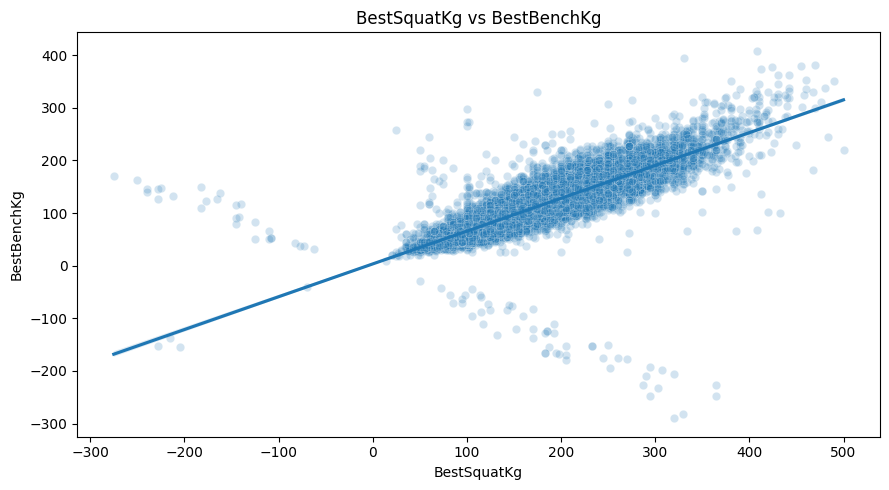

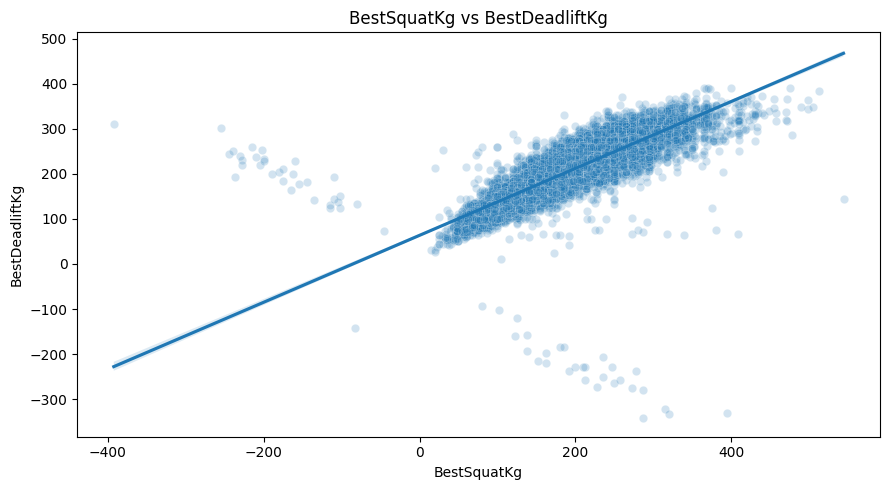

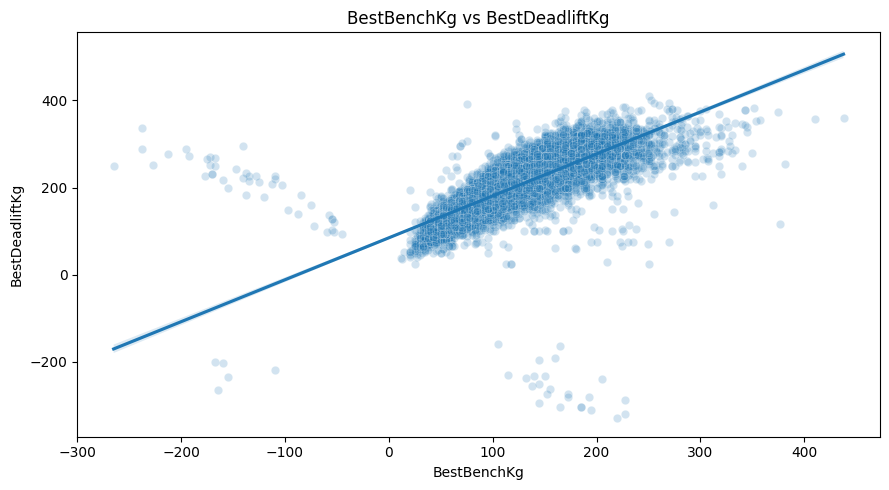

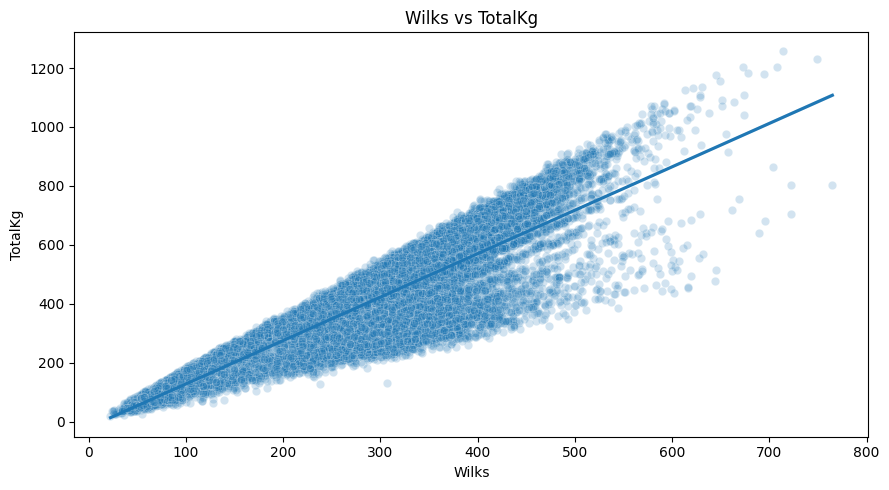

In [ ]:
# Important scatter relationships

pairs=[
    ("Age","TotalKg"),
    ("BodyweightKg","TotalKg"),
    ("BodyweightKg","BestSquatKg"),
    ("BodyweightKg","BestBenchKg"),
    ("BodyweightKg","BestDeadliftKg"),
    ("BestSquatKg","BestBenchKg"),
    ("BestSquatKg","BestDeadliftKg"),
    ("BestBenchKg","BestDeadliftKg"),
    ("Wilks","TotalKg")
]

for x,y in pairs:
    if x not in df or y not in df:
        continue

    p=df[[x,y]].dropna()
    if len(p)>20000:
        p=p.sample(20000,random_state=42)

    plt.figure(figsize=(9,5))
    sns.scatterplot(data=p,x=x,y=y,alpha=.20)
    sns.regplot(data=p,x=x,y=y,scatter=False)
    plt.title(f"{x} vs {y}")
    plt.tight_layout()
    plt.show()


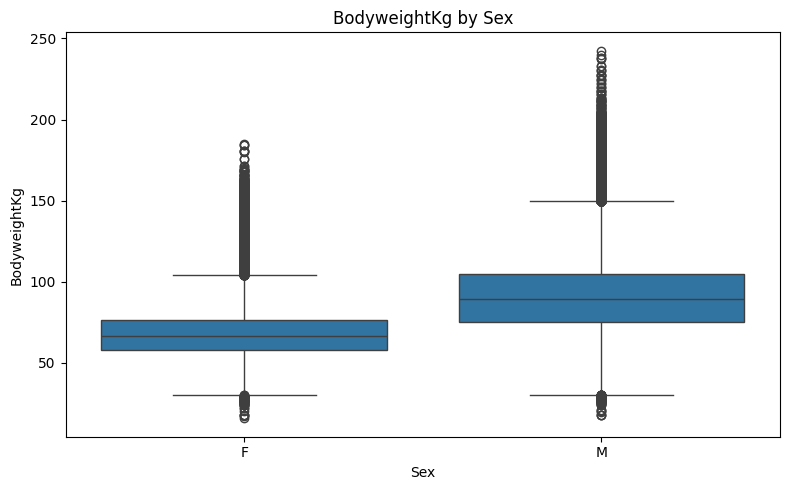

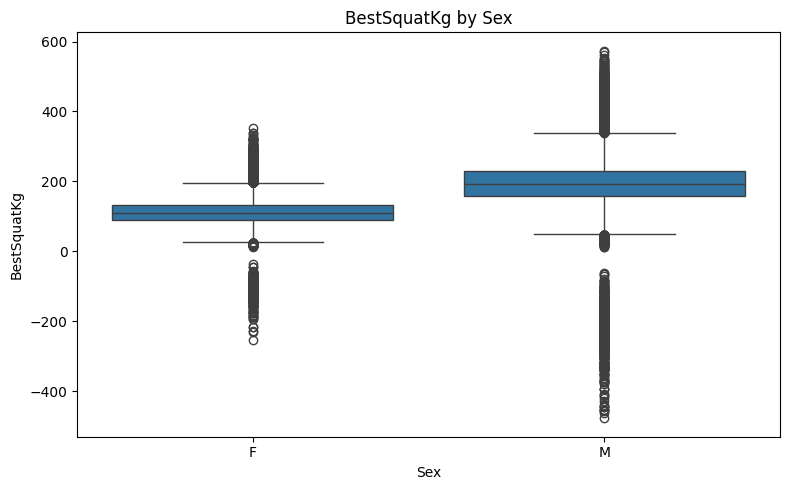

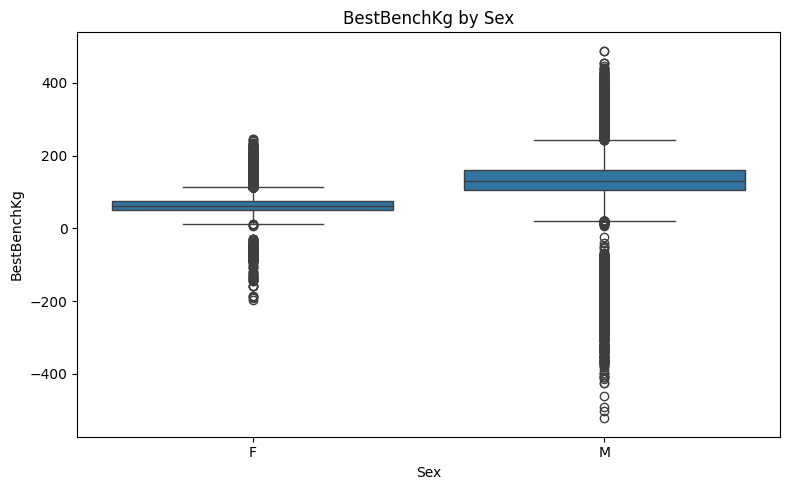

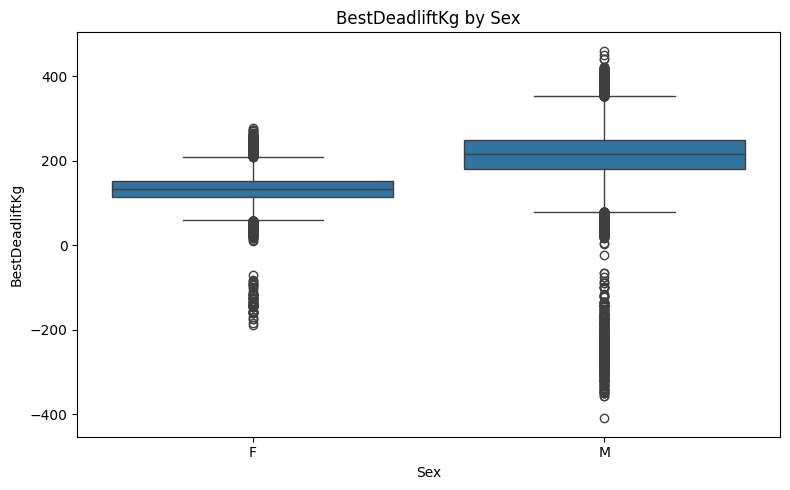

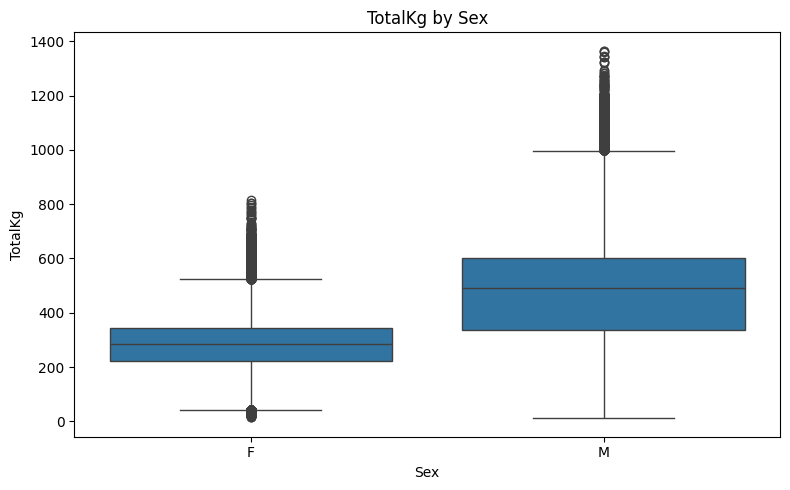

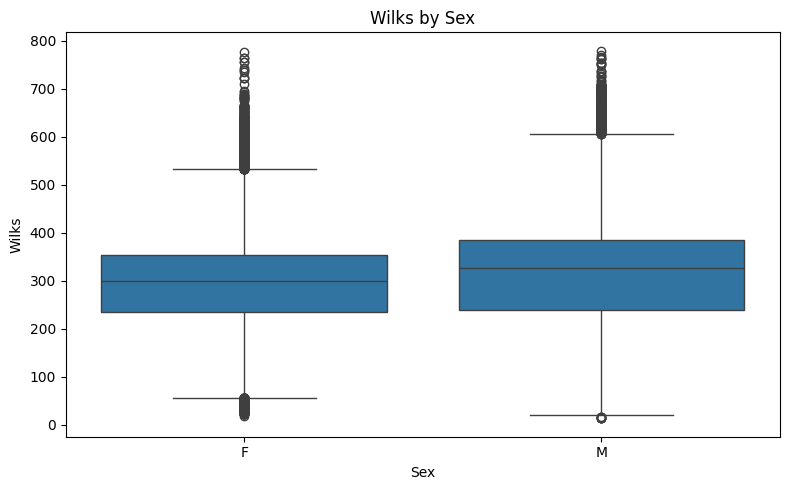

In [ ]:
# Sex vs major variables

if "Sex" in df:
    for y in ["BodyweightKg","BestSquatKg","BestBenchKg","BestDeadliftKg","TotalKg","Wilks"]:
        if y in df:
            plt.figure(figsize=(8,5))
            sns.boxplot(data=df,x="Sex",y=y)
            plt.title(f"{y} by Sex")
            plt.tight_layout()
            plt.show()


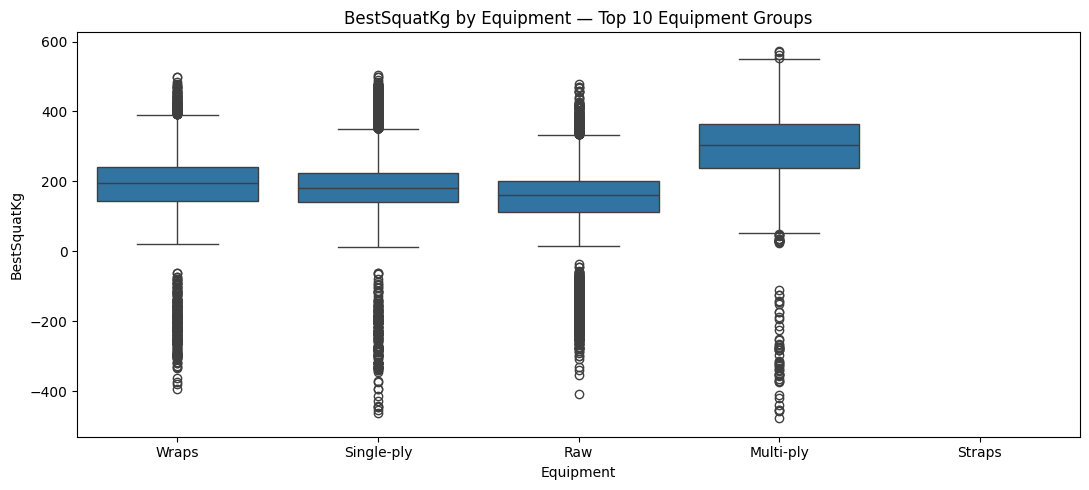

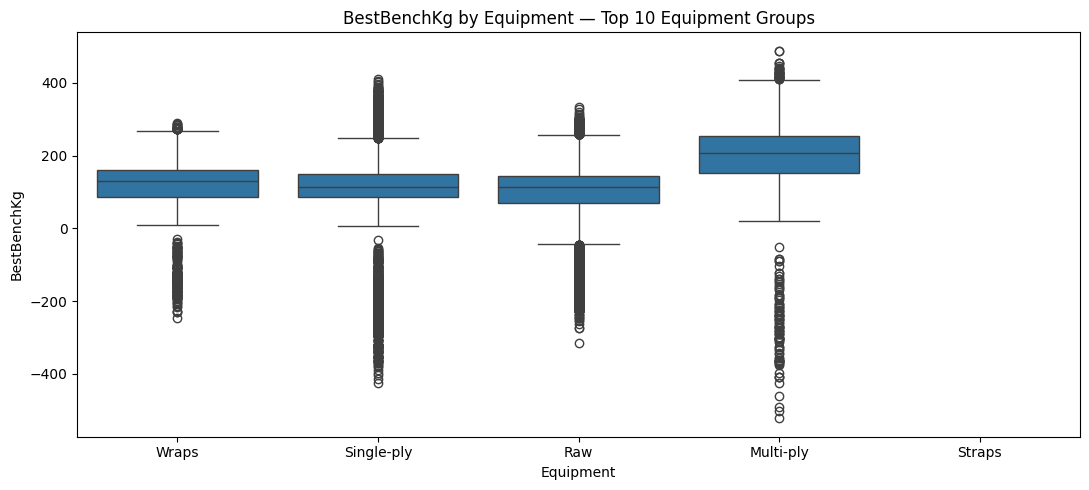

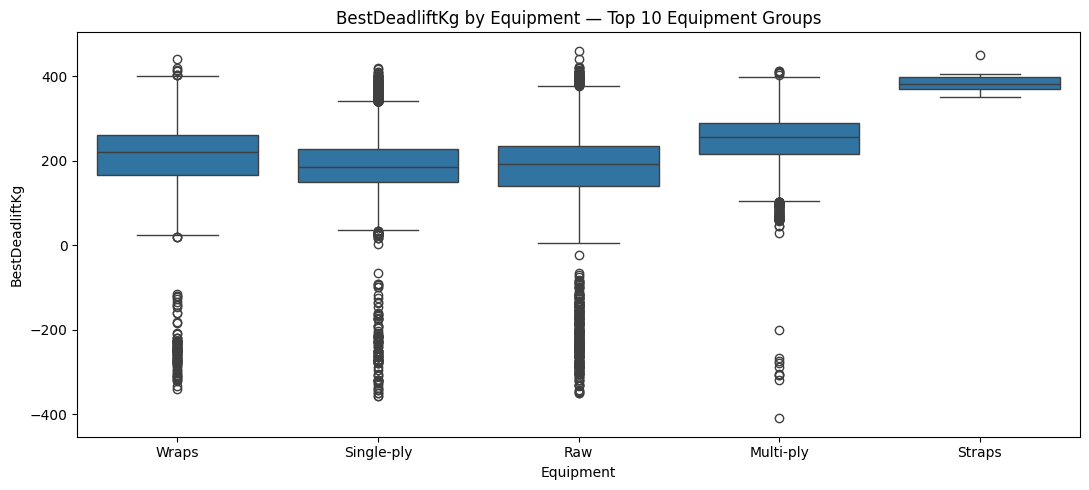

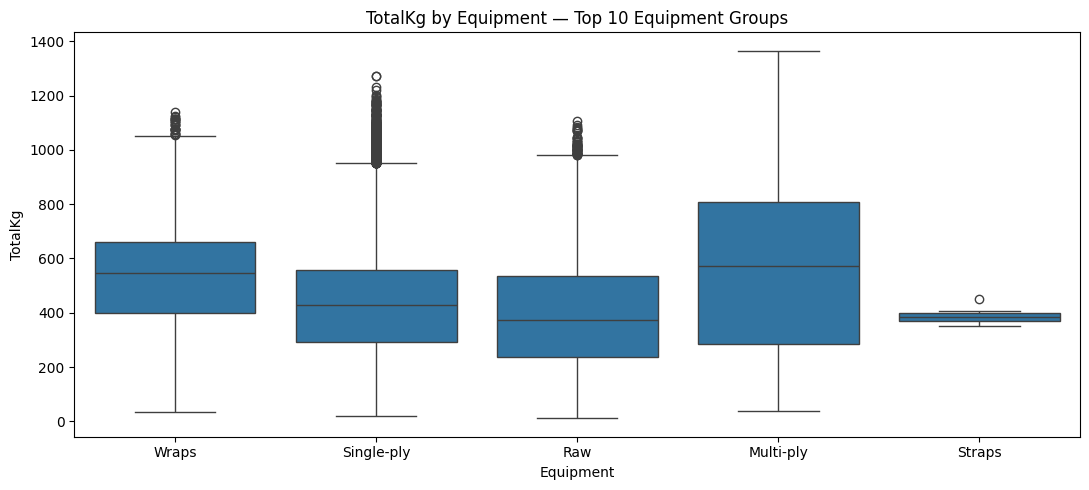

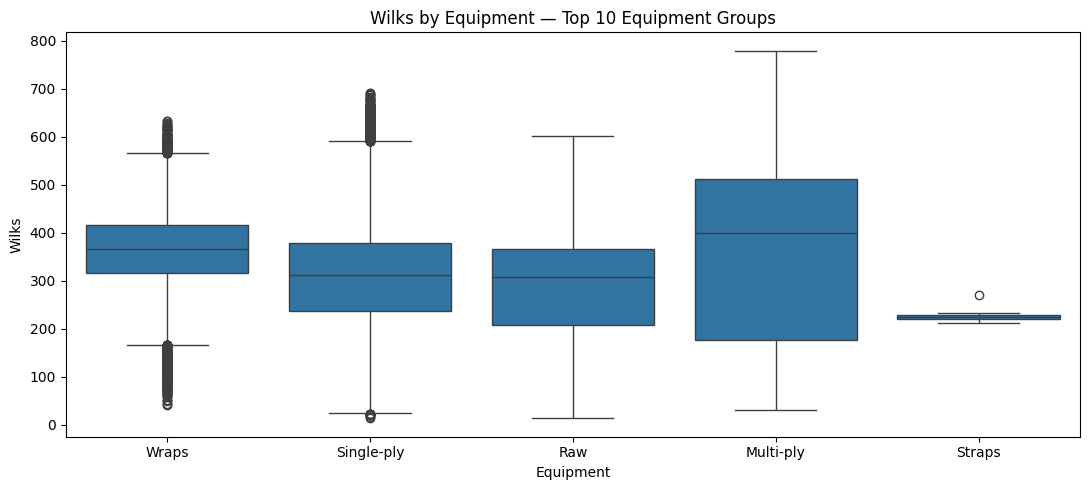

In [ ]:
# Equipment vs major variables

if "Equipment" in df:
    top_equipment=df["Equipment"].value_counts().head(10).index
    d=df[df["Equipment"].isin(top_equipment)]

    for y in ["BestSquatKg","BestBenchKg","BestDeadliftKg","TotalKg","Wilks"]:
        if y in d:
            plt.figure(figsize=(11,5))
            sns.boxplot(data=d,x="Equipment",y=y)
            plt.title(f"{y} by Equipment — Top 10 Equipment Groups")
            plt.tight_layout()
            plt.show()


Target column Oriented

In [ ]:
# Target configuration

target="TotalKg"

assert target in df.columns
print("Target:",target)
print(df[target].describe())


Target: TotalKg
count    363237.000000
mean        424.000249
std         196.355147
min          11.000000
25%         272.160000
50%         424.110000
75%         565.000000
max        1365.310000
Name: TotalKg, dtype: float64


In [ ]:
# numerical feature vs target

candidate_num=[c for c in numeric_cols if c!=target]

target_corr=(
    df[candidate_num+[target]]
    .corr()[target]
    .drop(target)
    .sort_values(key=lambda x:x.abs(),ascending=False)
)

print(target_corr.to_frame("Pearson_Correlation"))


                Pearson_Correlation
BestSquatKg                0.964607
Wilks                      0.878689
BestDeadliftKg             0.864350
BestBenchKg                0.551289
BodyweightKg               0.405702
Age                       -0.176442
Squat4Kg                   0.164716
Deadlift4Kg                0.062083
Bench4Kg                   0.051416
MeetID                     0.006375


Multivariate Analysis

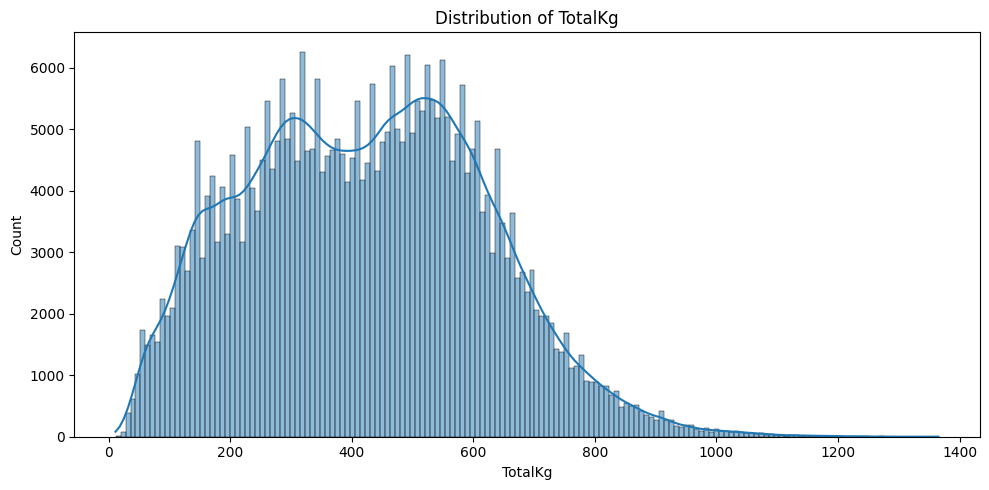

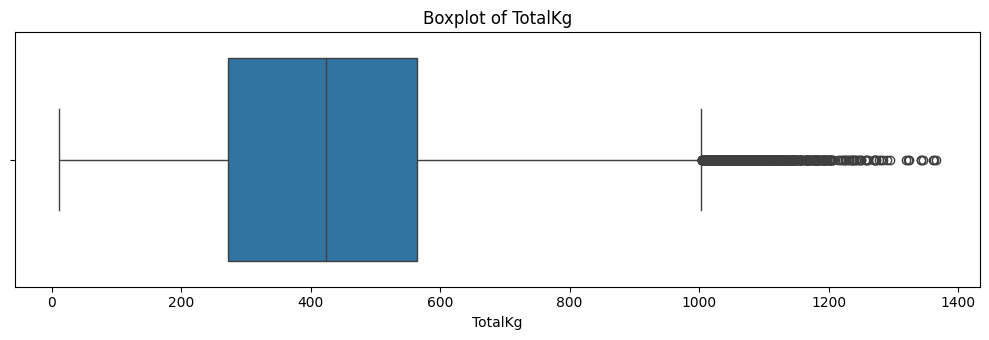

In [ ]:
# Target distribution

plt.figure(figsize=(10,5))
sns.histplot(df[target].dropna(),kde=True)
plt.title(f"Distribution of {target}")
plt.xlabel(target)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,3.5))
sns.boxplot(x=df[target])
plt.title(f"Boxplot of {target}")
plt.tight_layout()
plt.show()


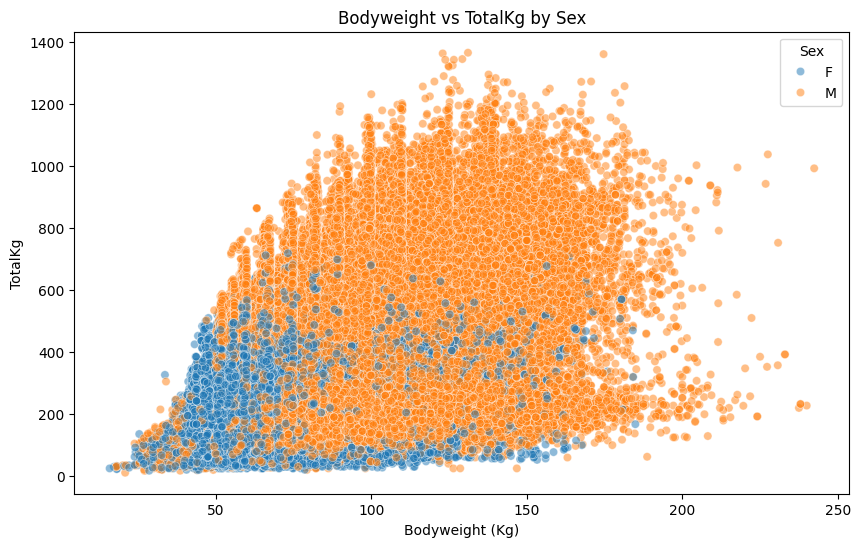

In [ ]:
# Bodyweight + Sex + TotalKg
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="BodyweightKg",
    y="TotalKg",
    hue="Sex",
    alpha=0.5
)

plt.title("Bodyweight vs TotalKg by Sex")
plt.xlabel("Bodyweight (Kg)")
plt.ylabel("TotalKg")
plt.show()


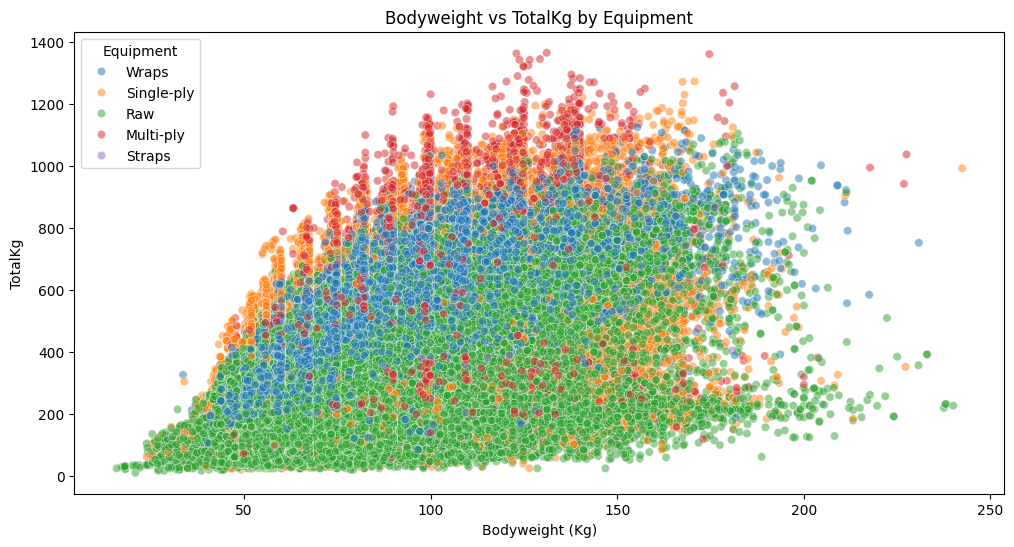

In [ ]:

# Bodyweight + Equipment + TotalKg
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=df,
    x="BodyweightKg",
    y="TotalKg",
    hue="Equipment",
    alpha=0.5
)

plt.title("Bodyweight vs TotalKg by Equipment")
plt.xlabel("Bodyweight (Kg)")
plt.ylabel("TotalKg")
plt.show()

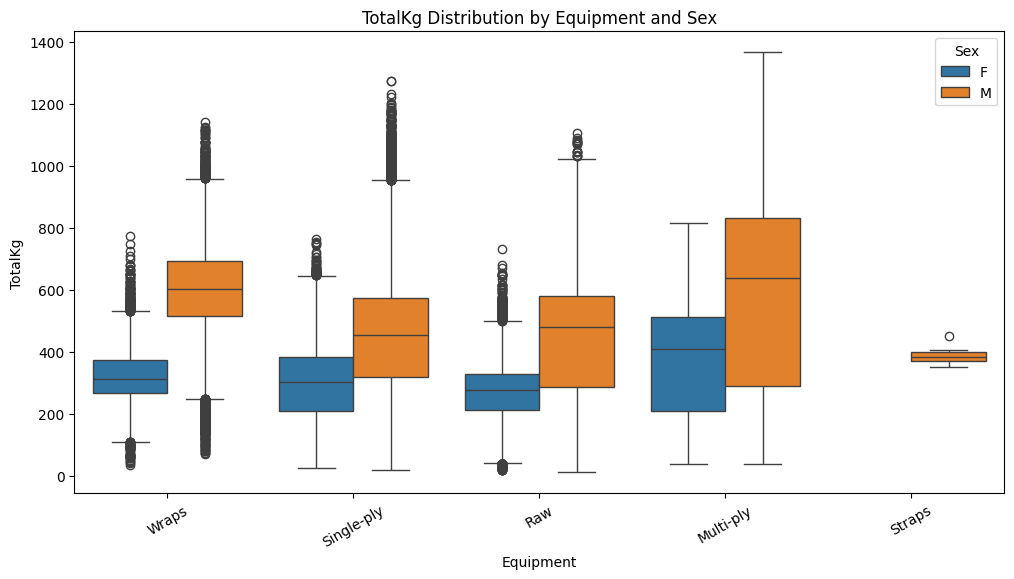

In [ ]:
# Sex + Equipment + TotalKg
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="Equipment",
    y="TotalKg",
    hue="Sex"
)

plt.title("TotalKg Distribution by Equipment and Sex")
plt.xlabel("Equipment")
plt.ylabel("TotalKg")
plt.xticks(rotation=30)
plt.show()

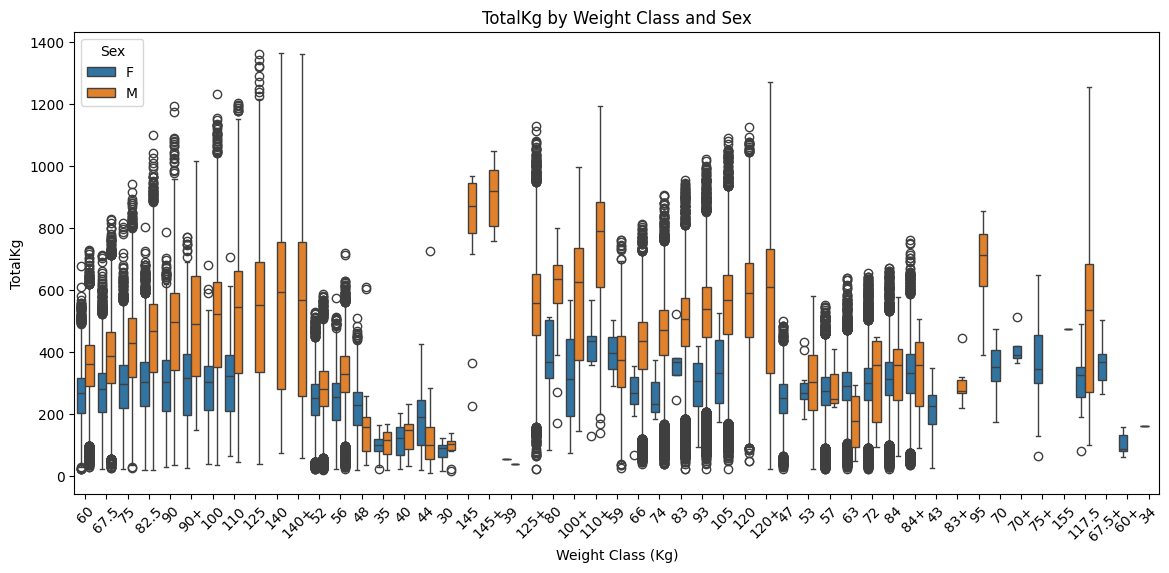

In [ ]:
# Sex + WeightClassKg + TotalKg
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df,
    x="WeightClassKg",
    y="TotalKg",
    hue="Sex"
)

plt.title("TotalKg by Weight Class and Sex")
plt.xlabel("Weight Class (Kg)")
plt.ylabel("TotalKg")
plt.xticks(rotation=45)
plt.show()

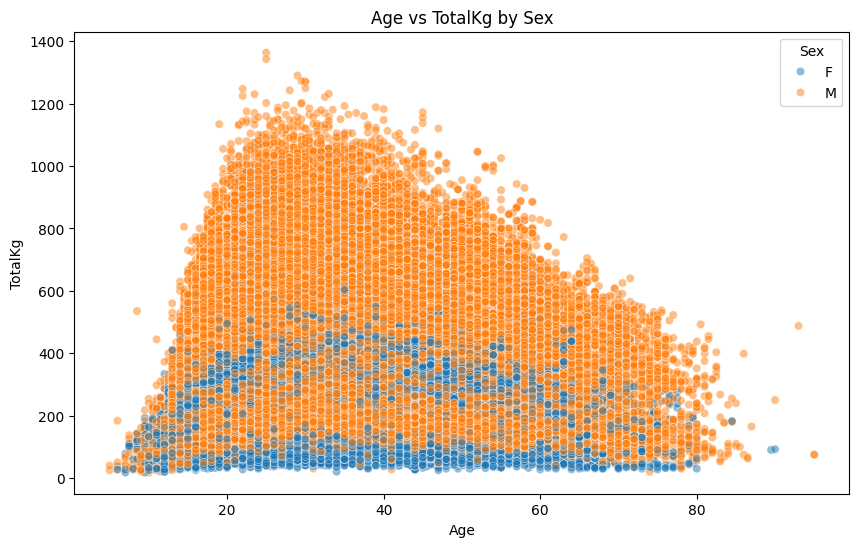

In [ ]:
# Age + Sex + TotalKg
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Age",
    y="TotalKg",
    hue="Sex",
    alpha=0.5
)

plt.title("Age vs TotalKg by Sex")
plt.xlabel("Age")
plt.ylabel("TotalKg")
plt.show()



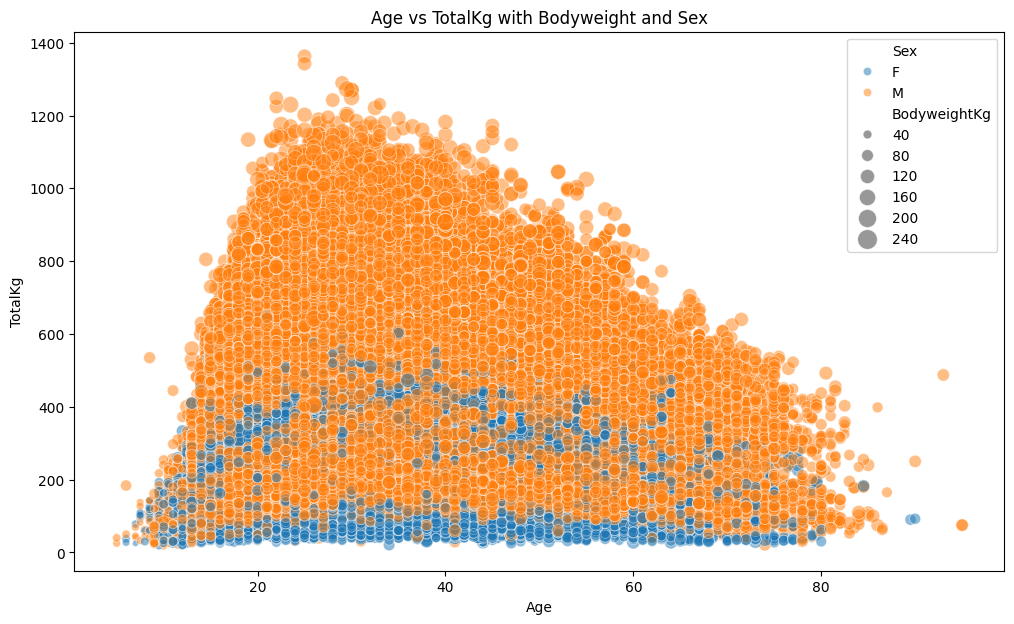

In [ ]:
# Bodyweight + Age + TotalKg
# Here we use point size/color to represent a third variable:

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="Age",
    y="TotalKg",
    hue="Sex",
    size="BodyweightKg",
    sizes=(20, 200),
    alpha=0.5
)

plt.title("Age vs TotalKg with Bodyweight and Sex")
plt.xlabel("Age")
plt.ylabel("TotalKg")
plt.show()



/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


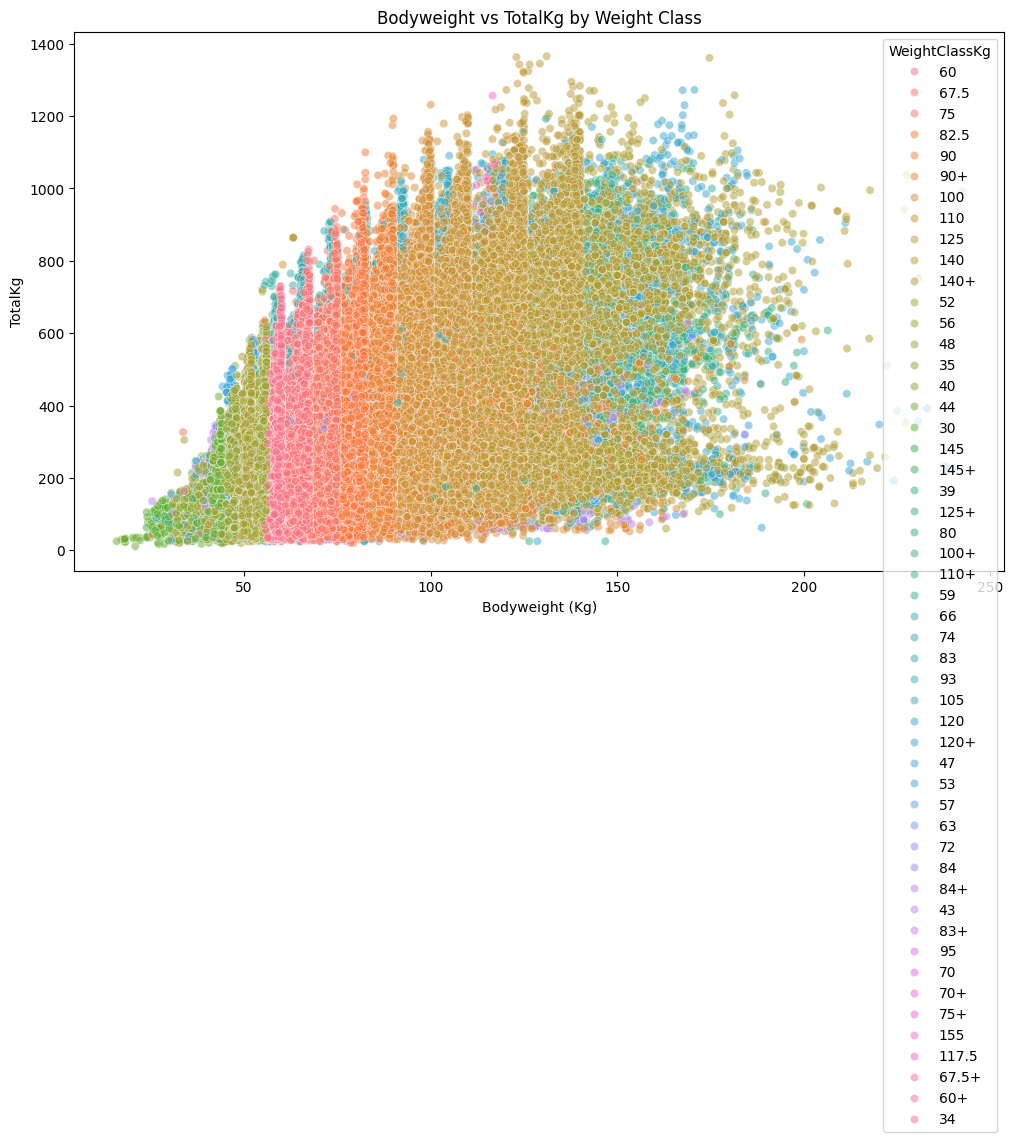

In [ ]:
# Bodyweight + WeightClass + TotalKg
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="BodyweightKg",
    y="TotalKg",
    hue="WeightClassKg",
    alpha=0.5
)

plt.title("Bodyweight vs TotalKg by Weight Class")
plt.xlabel("Bodyweight (Kg)")
plt.ylabel("TotalKg")
plt.show()



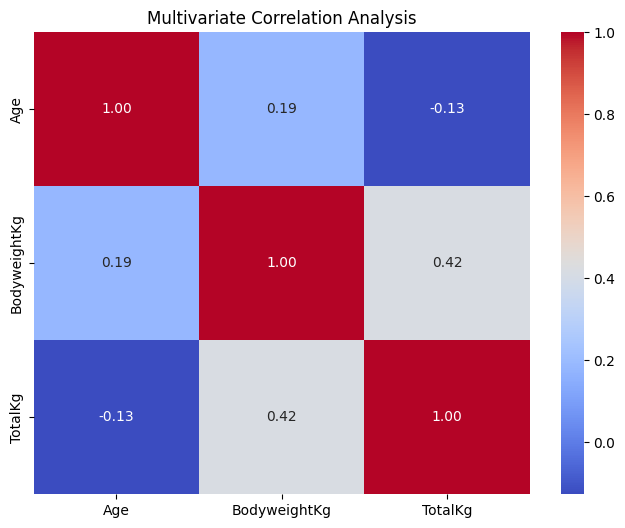

In [ ]:
#  Multiple Numerical Features
# don't include BestSquatKg, BestBenchKg, and BestDeadliftKg when evaluating predictors of TotalKg, because they directly form the target.

safe_numeric_cols = [
    "Age",
    "BodyweightKg",
    "TotalKg"
]

corr = df[safe_numeric_cols].corr(method="spearman")

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Multivariate Correlation Analysis")
plt.show()



In [ ]:
# Grouped Multivariate Analysis
# This is particularly useful for your project because it combines Sex + Equipment + Weight Class + TotalKg.

grouped = (
    df.groupby(["Sex", "Equipment", "WeightClassKg"])["TotalKg"]
      .agg(["count", "mean", "median", "std"])
      .reset_index()
)

grouped.sort_values("mean", ascending=False).head(20)

,Sex,Equipment,WeightClassKg,count,mean,median,std
176,M,Single-ply,145+,9,904.722222,920.000,107.887705
211,M,Wraps,125+,30,890.916667,895.000,92.644303
164,M,Single-ply,100+,2,886.250000,886.250,136.118055
175,M,Single-ply,145,15,881.333333,912.500,82.585814
107,M,Multi-ply,110+,16,871.870625,916.240,259.709089
167,M,Single-ply,110+,46,851.684348,870.000,143.971814
213,M,Wraps,140+,1139,746.278112,748.430,146.228963
208,M,Wraps,110+,75,742.839333,775.000,154.009844
214,M,Wraps,145,1,734.990000,734.990,NaN
212,M,Wraps,140,1890,708.832762,715.000,132.865351


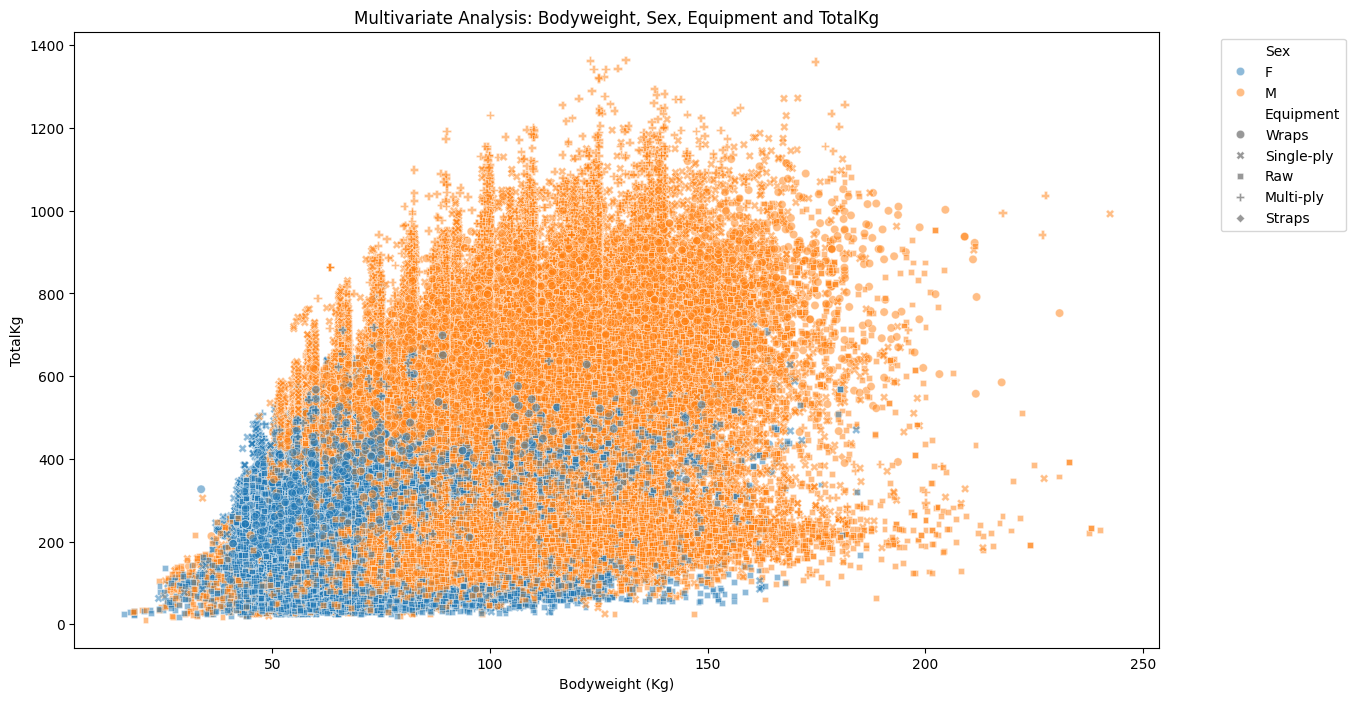

In [ ]:
plt.figure(figsize=(14, 8))

sns.scatterplot(
    data=df,
    x="BodyweightKg",
    y="TotalKg",
    hue="Sex",
    style="Equipment",
    alpha=0.5
)

plt.title("Multivariate Analysis: Bodyweight, Sex, Equipment and TotalKg")
plt.xlabel("Bodyweight (Kg)")
plt.ylabel("TotalKg")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

# EDA Observations

## 1. Dataset Size

- The dataset contains **386,414 rows** and **17 columns**.
- It is a large dataset, so it is suitable for machine learning.
- The dataset contains information about athletes, competitions, body weight, equipment, and lifting performance.

---

## 2. Target Variable — `TotalKg`

- `TotalKg` is our **target variable**.
- It represents the total weight lifted by an athlete.
- It is calculated using the best squat, bench press, and deadlift.

```text
TotalKg = BestSquatKg + BestBenchKg + BestDeadliftKg
Since TotalKg is a continuous numerical value, this is a Regression Problem.
3. Missing Values
The dataset contains missing values in several columns.
Age has a large number of missing values.
The 4th attempt columns have extremely high missing values.
Some performance columns also contain missing values.
Important Missing Values
Age → around 62% missing
Squat4Kg → around 99.7% missing
Bench4Kg → around 99.5% missing
Deadlift4Kg → around 99.3% missing
TotalKg → around 6% missing
Missing values should be handled carefully during preprocessing.
Rows with missing TotalKg cannot be used for supervised training because TotalKg is our target.
4. Fourth Attempt Columns

The following columns have very high missing values:

Squat4Kg
Bench4Kg
Deadlift4Kg
More than 99% of their values are missing.
Therefore, these columns may not be useful for the final ML model.
They can still be studied during EDA because they provide information about 4th attempts.
5. Age
Age can be useful for predicting lifting performance.
However, around 62% of Age values are missing.
Because of this, we need to carefully decide how to handle Age.
We should not simply remove all rows with missing age because that would remove a large part of the dataset.
6. Sex
The dataset contains both male and female athletes.
Male athletes have a higher average TotalKg than female athletes.
Therefore, Sex appears to be an important feature for predicting total lifting performance.
We should keep Sex as a possible ML feature.
7. Equipment
Different athletes use different types of equipment.
Equipment has a strong relationship with TotalKg.
Athletes using supportive equipment such as multi-ply equipment generally show higher total lifting performance.
Raw lifting also has a large number of athletes.
Observation
Equipment → TotalKg
Therefore, Equipment is an important feature to consider for the ML model.
8. Bodyweight
BodyweightKg has a positive relationship with TotalKg.
In general, heavier athletes tend to lift more total weight.
However, bodyweight alone does not completely explain performance.
Other factors such as sex, equipment, age, and weight class also affect performance.
Observation
Higher Bodyweight
        ↓
Generally Higher TotalKg
Therefore, BodyweightKg is an important feature.
9. Best Squat, Bench and Deadlift

The dataset contains:

BestSquatKg
BestBenchKg
BestDeadliftKg

These columns have a strong relationship with TotalKg.

However, there is an important problem.

TotalKg =
BestSquatKg
+ BestBenchKg
+ BestDeadliftKg

Therefore, these columns directly create our target.

Decision

We should not use these three columns as input features when predicting TotalKg.

Otherwise, the model will suffer from target leakage.

10. Wilks
Wilks has a strong relationship with TotalKg.
Wilks is a performance score that considers bodyweight.
However, Wilks is itself calculated using lifting performance and bodyweight.
Therefore, it is not a completely independent feature.
Decision

For a clean ML model, Wilks should be carefully considered and may be excluded from the final feature set.

11. Place
Place represents the athlete's finishing position.
Place depends on the other athletes competing in the same competition.
Therefore, it is not a simple measure of an athlete's ability.
The same athlete could get a different place in different competitions.
Decision

Place should generally not be used as a feature for predicting TotalKg.

12. MeetID
MeetID identifies a particular competition.
It is an identifier, not a meaningful numerical measurement.
The number itself does not represent athlete performance.
Decision

MeetID should normally be removed from the ML features.

However, it is useful during EDA to analyze competition-level patterns.

13. Name
Name contains the athlete's name.
Many different rows can belong to the same athlete because an athlete can participate in multiple competitions.
It has very high cardinality.
Using names directly as a feature is not useful for our main model.
Decision

Name should be removed from the ML features.

14. Division
Division contains information about the competition division.
There are many different division categories.
Therefore, it is a high-cardinality categorical feature.
One-hot encoding all division values may create a very large number of features.
Decision

We need to carefully investigate Division before using it in the final model.

15. Weight Class
WeightClassKg represents the athlete's competition weight class.
It can provide useful information about expected lifting performance.
There are many different weight classes.
It can potentially be used as a categorical feature.
Decision

WeightClassKg is a potential useful feature.

16. Duplicate Rows
The dataset contains some exact duplicate rows.
Approximately 545 duplicate rows were identified.
These duplicates should be investigated and handled during data cleaning.
Important

We should not remove rows simply because the same athlete appears multiple times.

An athlete can legitimately participate in multiple competitions.

17. Outliers
Some columns contain very large values.
For example, some athletes have very high bodyweight or lifting values.
These values appear as statistical outliers.

However:

An outlier is not always an incorrect value.

In powerlifting, very high lifting values can be legitimate.

Decision
We should investigate extreme values.
We should not automatically remove all outliers.
Domain knowledge should be used before removing them.
18. Negative Values
Some attempt columns contain negative values.
In powerlifting data, negative attempt values can represent failed attempts.
Therefore, negative values should not automatically be considered errors.
Decision

We should understand the meaning of negative attempt values before removing them.

19. TotalKg Consistency

We can verify whether:

BestSquatKg + BestBenchKg + BestDeadliftKg

matches:

TotalKg
The values are generally consistent.
Small differences can occur because of numerical precision or rounding.
Therefore, a small tolerance should be used when checking equality.
20. Target Missing Values
TotalKg has approximately 6% missing values.
Since TotalKg is our target, we should not simply impute the missing target values.
Rows where TotalKg is missing should normally be removed from the supervised ML training dataset.
TotalKg is missing
        ↓
Cannot calculate target
        ↓
Remove from training data